# Seção 01: Arquitetura do NVFlare

## Visão Geral: O que é o NVFlare e por que ele existe

O **NVIDIA Federated Learning Application Runtime Environment (NVFlare)** é um framework de código aberto projetado para permitir o treinamento colaborativo e distribuído de modelos de Aprendizado de Máquina (ML) e Deep Learning sem a necessidade de centralização de dados sensíveis.

No modelo tradicional de aprendizado centralizado, todos os dados brutos devem ser exportados e concentrados em um repositório central. No **Aprendizado Federado (FL)**, os dados permanecem estritamente dentro de seus limites institucionais originais (conhecidos no NVFlare como **sites** ou **clientes**). Apenas os parâmetros do modelo (`state_dict`), gradientes e métricas agregadas são transmitidos através da rede.


In [4]:
try:
    import nvflare
    print(f"NVFlare já instalado. Versão: {nvflare.__version__}")
except ImportError:
    !pip install nvflare -q
    import nvflare
    print(f"NVFlare instalado com sucesso. Versão: {nvflare.__version__}")


NVFlare já instalado. Versão: 2.9.0


## Planos de Controle vs. Execução no NVFlare

A arquitetura do NVFlare é dividida em dois planos:

1. **Plano de Controle (Server Side / Orquestrador)**:
   - Gerencia o ciclo de vida do job (nome padrão que eles usam para o servidor).
   - Distribui o modelo global inicial para os clientes.
   - Executa algoritmos de agregação federada (ex: `FedAvg`, `FedProx`).
   - Monitora o progresso de cada rodada global.

2. **Plano de Execução (Client Side / Sites)**:
   - Recebe o modelo global do servidor a cada rodada.
   - Executa o treinamento local utilizando a infraestrutura e os dados do cliente.
   - Computa a avaliação no conjunto de validação local.
   - Devolve os pesos atualizados (`FLModel`) para o servidor.

```
   ┌───────────────────────────────────────────┐
   │              Servidor FL                  │
   │  (Orquestrador / Aggregator / Controller) │
   └────────────────────┬──────────────────────┘
                        │ (FLModel: state_dict + metrics)
      ┌─────────────────┴─────────────────┐
      ▼                                   ▼
┌───────────┐                       ┌───────────┐
│ Cliente 1 │                       │ Cliente 2 │
│  (Site-1) │                       │  (Site-2) │
└───────────┘                       └───────────┘
```

Consegue tranformar em mermaid pra colocar numa celula de um jupyter notebook?

## Componentes Centrais de Orquestração no NVFlare

| Componente | Papel Arquitetural | Função no Pipeline |
|---|---|---|
| `ScatterAndGather` | Workflow do Servidor | Dispara o modelo para os clientes e aguarda a recepção dos resultados de volta |
| `InTimeAccumulateWeightedAggregator` | Agregador | Realiza a média ponderada (FedAvg) das atualizações enviadas pelos clientes ativos |
| `FedAvgRecipe` | Configurações da Sim. | Empacota servidores, clientes, agregadores e tracking em um único objeto configurável |
| `SimEnv` | Ambiente de Simulação | Executa múltiplos clientes em subprocessos/threads na mesma máquina para fins didáticos e de testes |


## Visão Geral da Client API do NVFlare

A **Client API** do NVFlare desacopla completamente o código do modelo do framework de comunicação federada.

| Função API | Descrição |
|---|---|
| `flare.init()` | Inicializa a comunicação entre o script do cliente e o subprocesso do NVFlare |
| `flare.get_site_name()` | Retorna o identificador único do cliente (ex: `"site-1"`) |
| `flare.is_running()` | Retorna `True` enquanto a simulação federada permanecer ativa |
| `flare.receive()` | Bloqueia até receber o objeto `FLModel` com os novos pesos enviados pelo servidor |
| `flare.send(model)` | Envia o modelo treinado localmente (`FLModel`) de volta para agregação |


In [ ]:
if False:
    import nvflare.client as flare
    
    flare.init()  # Inicializa canal de comunicação
    
    while flare.is_running():
        input_model = flare.receive()  # Recebe FLModel do servidor
        if input_model is None:
            break
        
        # Treinamento local usando input_model.params ...
        
        output_model = flare.FLModel(params=net.state_dict(), metrics={"accuracy": 0.90})
        flare.send(output_model)  # Transmite pesos atualizados para o servidor


## Modos de Execução do NVIDIA FLARE

O NVIDIA FLARE oferece três modos principais de operação para atender a diferentes etapas do ciclo de desenvolvimento de Aprendizado Federado (FL): da depuração local à implantação segura em larga escala.

---

### 1. Modo Simulador (`nvflare simulator`)

Projetado para **prototipagem rápida e depuração** de código na máquina do desenvolvedor.

* **Infraestrutura:** Roda estritamente em uma **única máquina** (localhost).
* **Mecanismo:** Cria processos leves ou threads no mesmo host para simular o servidor e múltiplos clientes federados.
* **Comunicação:** Ocorre localmente (sem necessidade de conexões de rede ativas ou roteamento complexo).
* **Quando usar:**
  * Testar e debugar novas estratégias de agregação (ex: FedAvg, FedProx).
  * Validar a lógica do modelo e dos loops de treinamento antes de lidar com infraestrutura.
  * Desenvolvimento rápido sem sobrecarga de configuração de certificados ou portas.

---

### 2. Modo Prova de Conceito (`POC Mode`)

A etapa intermediária entre a simulação e o ambiente de produção. Permite testar a orquestração real do sistema com configuração simplificada.

* **Infraestrutura:** Pode rodar tanto em uma única máquina (múltiplos terminais) quanto **distribuído entre diferentes máquinas/VMs na rede local**.
* **Mecanismo:** Servidor, clientes e console de administração rodam como processos independentes e comunicam-se via **gRPC**.
* **Segurança:** Simplificada/aberta (ideal para redes locais seguras), eliminando a burocracia de emissão manual de PKI complexa.
* **Quando usar:**
  * Validar a troca de mensagens de rede e latência entre nós físicos distintos.
  * Treinar a equipe no uso da CLI do administrador (`nvflare job submit`, monitoramento de nós).
  * Testes de integração em laboratório antes do provisionamento formal.

---

### 3. Modo Produção (`Provisioned Deployment`)

O ambiente completo para **implantação federada corporativa ou entre instituições**.

* **Infraestrutura:** Totalmente **distribuído**, frequentemente conectando nós geograficamente dispersos (hospitais, centros de pesquisa, nuvens híbridas).
* **Mecanismo:** Baseado em um processo formal de provisionamento (`project.yml`), gerando pacotes isolados para cada participante.
* **Segurança:** Autenticação mTLS obrigatória (certificados X.509 para cada cliente, servidor e usuário admin), isolamento estrito de permissões e auditoria de jobs.
* **Quando usar:**
  * Consórcios reais de Aprendizado Federado com múltiplos detentores de dados (*data owners*).
  * Ambientes em conformidade com regulações estritas de privacidade (ex: LGPD, HIPAA).
  * Produção contínua e pipelines federados de longo prazo.

---

### Tabela Comparativa

| Característica | Simulador | Modo POC | Produção (Provisioned) |
| :--- | :--- | :--- | :--- |
| **Distribuição Física** | 1 máquina (Local) | 1 ou várias máquinas | Múltiplas máquinas/redes |
| **Protocolo de Rede** | Em memória / Local | gRPC real na rede | gRPC com mTLS obrigatório |
| **Segurança / Certificados** | Inexistente | Simplificada (aberta) | Completa (PKI / mTLS / RBAC) |
| **Complexidade de Setup** | Mínima (1 comando CLI) | Baixa (scripts locais) | Média/Alta (`project.yml`) |
| **Foco Principal** | Algoritmos e depuração | Integração e fluxo de rede | Segurança e operação real |

# Seção 02: Modelos Suportados no Ecossistema NVFlare

## NVFlare é Agnóstico a Frameworks de Machine Learning

O NVFlare transmite dados de tensores e coleções de dicionários de parâmetros. Dessa forma, ele suporta os principais frameworks de IA e ML do mercado.

---

### 1. PyTorch

O PyTorch é a integração nativa primária do NVFlare. Os dicionários `state_dict()` dos modelos `nn.Module` são transmitidos diretamente via `FLModel`.

#### Quando usar:
Visão computacional, processamento de linguagem natural, aprendizado por reforço e qualquer modelo deep learning baseado em PyTorch.


In [6]:
# Exemplo executável de passagem pelo modelo PyTorch e verificação de state_dict
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(16, 10)
)

dummy_x = torch.randn(2, 3, 32, 32)
output = model(dummy_x)

print(f"Saída do modelo PyTorch (Shape): {output.shape}")
print(f"Chaves do state_dict PyTorch: {list(model.state_dict().keys())}")


Saída do modelo PyTorch (Shape): torch.Size([2, 10])
Chaves do state_dict PyTorch: ['0.weight', '0.bias', '4.weight', '4.bias']


### 2. TensorFlow / Keras

No TensorFlow/Keras, os pesos dos modelos (`model.get_weights()`) são representados como listas de matrizes NumPy e encapsulados no `FLModel` do NVFlare.

#### Quando usar:
Sistemas corporativos com pipelines legados em TensorFlow ou TensorFlow Lite.


In [7]:
# Exemplo ilustrativo — não execute neste ambiente
if False:
    import tensorflow as tf
    import nvflare.client as flare

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10)
    ])
    # Os pesos são extraídos com model.get_weights() e atribuídos ao FLModel


### 3. Scikit-Learn

O NVFlare permite o treinamento federado de modelos tabulares clássicos através de algoritmos de aprendizado online e incremental (ex: `partial_fit` em `SGDClassifier` e `SGDRegressor`).

#### Quando usar:
Modelos tabulares de regressão logística, regressão linear e classificadores lineares em dados tabulares.


In [8]:
# Exemplo ilustrativo — não execute neste ambiente
if False:
    from sklearn.linear_model import SGDClassifier
    import nvflare.client as flare

    clf = SGDClassifier(loss='log_loss')
    # Treinamento incremental via clf.partial_fit(X_batch, y_batch, classes=np.arange(10))


### 4. XGBoost Federado

O NVFlare possui suporte nativo a gradiente boosting federado em topologias horizontais (clientes compartilham as mesmas colunas/features, mas instâncias diferentes) e verticais (clientes compartilham os mesmos indivíduos, mas features diferentes com Private Set Intersection - PSI).

#### Quando usar:
Análise de risco financeiro, detecção de fraude e dados tabulares de alta performance.


In [9]:
# Exemplo ilustrativo — não execute neste ambiente
if False:
    import xgboost as xgb
    import nvflare.client as flare

    # Treinamento de árvores de decisão federadas (Horizontal / Vertical / PSI)


### 5. FedLLM (Large Language Models)

No ecossistema de LLMs, a transmissão de bilhões de parâmetros é inviável devido à largura de banda. O NVFlare integra-se com **Hugging Face PEFT / LoRA** e **NVIDIA NeMo**, onde apenas os adaptadores LoRA (frações de 1% dos parâmetros) são transmitidos entre os nós.

#### Quando usar:
Fine-tuning federado de LLMs (ex: Llama, Mistral) em ambientes hospitalares ou financeiros restritos.


In [ ]:
# Exemplo ilustrativo — não execute neste ambiente
if False:
    # Fine-tuning federado de LLMs com Hugging Face PEFT / LoRA
    # Apenas os adaptadores LoRA (frações de 1% dos parâmetros) são transmitidos
    pass


## Resumo da Compatibilidade de Frameworks no NVFlare

| Framework | Caso de Uso Principal | Tipo de Dado | Abordagem de Integração no NVFlare |
|---|---|---|---|
| **PyTorch** | Deep Learning / Visão / NLP | Tensores | Client API nativa (`FLModel` com `state_dict`) |
| **TensorFlow** | Deep Learning Corporativo | Tensores | Converters de arrays NumPy em `FLModel` |
| **Scikit-Learn** | Regressão / Classificação Tabular | Arrays NumPy | Média de coeficientes / `partial_fit` |
| **XGBoost** | Tabular de Alta Performance | DMatrix | Executor dedicado XGBoost (Horizontal / Vertical) |
| **FedLLM (PEFT/LoRA)** | Fine-tuning de Grandes Modelos | Adaptadores LoRA | Transmissão exclusiva dos pesos de adaptadores LoRA |


# Bloco C: Anatomia de Redes Neurais em PyTorch para Aprendizado Federado

## Compreendendo a Estrutura de Modelos no Aprendizado Federado

Para que o Aprendizado Federado funcione de maneira eficiente, é fundamental compreender a anatomia interna do modelo neural e como as camadas afetam a comunicação e a convergência.


## Tipos de Camadas em Redes Neurais Convolucionais

- **Conv2d (Camada Convolucional)**: Extrai mapas de características espaciais (bordas, texturas, formas) através do deslize de filtros aprendíveis.
- **MaxPool2d (Subamostragem)**: Reduz as dimensões espaciais mantendo os valores máximos, garantindo invariância a pequenas rotações e reduzindo a carga computacional.
- **Linear (Camada Densa / Totalmente Conectada)**: Combina as características extraídas pelas camadas convolucionais para realizar a classificação final (logits).
- **Dropout**: Camada de regularização que desativa aleatoriamente neurônios durante o treino para prevenir overfitting.


In [11]:
import torch
import torch.nn as nn

conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
pool = nn.MaxPool2d(2, 2)
fc = nn.Linear(32 * 8 * 8, 128)

x = torch.randn(1, 3, 32, 32)
out_conv = conv(x)
out_pool = pool(out_conv)
print(f"Entrada inicial: {x.shape}")
print(f"Após Conv2d(3, 16, 3, padding=1): {out_conv.shape}")
print(f"Após MaxPool2d(2, 2): {out_pool.shape}")


Entrada inicial: torch.Size([1, 3, 32, 32])
Após Conv2d(3, 16, 3, padding=1): torch.Size([1, 16, 32, 32])
Após MaxPool2d(2, 2): torch.Size([1, 16, 16, 16])


## Funções de Ativação: ReLU vs GELU

- **ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$. Eficiente computacionalmente, mas pode sofrer com "dying ReLU" quando os gradientes zeram para entradas negativas.
- **GELU (Gaussian Error Linear Unit)**: $f(x) = x \cdot \Phi(x)$. Suave e não monotônica, amplamente utilizada em arquiteturas modernas como Transformers e ViTs.


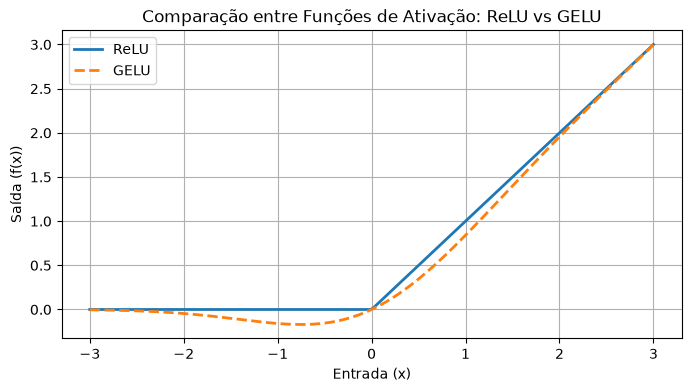

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 200)
y_relu = F.relu(x)
y_gelu = F.gelu(x)
# colocar a sigmoide

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y_relu.numpy(), label="ReLU", linewidth=2)
plt.plot(x.numpy(), y_gelu.numpy(), label="GELU", linewidth=2, linestyle="--")
plt.title("Comparação entre Funções de Ativação: ReLU vs GELU")
plt.xlabel("Entrada (x)")
plt.ylabel("Saída (f(x))")
plt.grid(True)
plt.legend()
plt.show()


## ⚠️ Alerta de Arquitetura: BatchNorm2d no Aprendizado Federado

### O Problema do BatchNorm2d sob Heterogeneidade de Dados (Não-IID)

As camadas de **Normalização em Lote (`nn.BatchNorm2d`)** mantêm estatísticas móveis durante o treinamento:
- `running_mean` (Média móvel dos dados)
- `running_var` (Variância móvel dos dados)

Em Aprendizado Federado não-IID (onde o Cliente 1 possui apenas imagens de cachorros e o Cliente 2 apenas imagens de aviões):
1. O Cliente 1 calcula um `running_mean` e `running_var` específicos para cachorros.
2. O Cliente 2 calcula estatísticas móveis completamente diferentes para aviões.
3. A agregação ingênua (`FedAvg`) dessas estatísticas resulta em estimadores corrompidos que degradam a acurácia do modelo global.

> **Regra Didática**: No modelo `SimpleCNN`, evitamos o uso de `BatchNorm2d` para garantir convergência estável em distribuições heterogêneas sem necessitar de técnicas complexas como Group Normalization ou Layer Normalization.


## Por que o Aprendizado Federado transmite apenas pesos e gradientes?

### Razão 1: Privacidade dos Dados
A transmissão dos dados brutos violaria regulamentações como LGPD e HIPAA. Os pesos e gradientes contêm apenas atualizações abstratas de representação.

### Razão 2: Eficiência de Largura de Banda
- O dataset CIFAR-10 de treino contém 50.000 imagens coloridas 32x32 = **~153 MB**.
- O modelo `SimpleCNN` possui 268.650 parâmetros em `float32` (4 bytes por parâmetro) = **~1.07 MB**.

Transmitir o modelo consome menos de **0.7%** do volume de dados brutos por rodada!


## Otimizadores no Treinamento Local: SGD vs Adam

- **SGD (Stochastic Gradient Descent)**: Atualização direta $\theta \leftarrow \theta - \eta \cdot g$. Mantém o comportamento previsível e funciona excepcionalmente bem em FedAvg.
- **Adam**: Otimizador adaptativo com estimativa de momentos de primeira ($m_t$) e segunda ($v_t$) ordem.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

num_passos = 7 # Quantidade de passo que tu quer ver
learning_rate = 0.01 # E bacana de mexer nesse, pra ver como as funções se comportam com a modificação dele.

model_sgd = nn.Linear(2, 1, bias=False)
model_adam = nn.Linear(2, 1, bias=False)

with torch.no_grad():
    model_sgd.weight.fill_(1.0)
    model_adam.weight.fill_(1.0)

opt_sgd = optim.SGD(model_sgd.parameters(), lr=learning_rate)
opt_adam = optim.Adam(model_adam.parameters(), lr=learning_rate)

dummy_in = torch.tensor([[2.0, 3.0]])
target = torch.tensor([[0.0]])

print("Peso inicial: [1.0, 1.0]\n")

for passo in range(1, num_passos + 1):
    # Passo SGD
    opt_sgd.zero_grad()
    loss_sgd = (model_sgd(dummy_in) - target).pow(2)
    loss_sgd.backward()
    opt_sgd.step()

    # Passo Adam
    opt_adam.zero_grad()
    loss_adam = (model_adam(dummy_in) - target).pow(2)
    loss_adam.backward()
    opt_adam.step()

    print(f"--- Passo {passo} ---")
    print(f"SGD  (Loss: {loss_sgd.item():.4f}): {model_sgd.weight.detach().numpy()[0]}")
    print(f"Adam (Loss: {loss_adam.item():.4f}): {model_adam.weight.detach().numpy()[0]}")

Peso inicial: [1.0, 1.0]

--- Passo 1 ---
SGD  (Loss: 25.0000): [0.8 0.7]
Adam (Loss: 25.0000): [0.99 0.99]
--- Passo 2 ---
SGD  (Loss: 13.6900): [0.652      0.47800002]
Adam (Loss: 24.5025): [0.98000276 0.98000276]
--- Passo 3 ---
SGD  (Loss: 7.4966): [0.54248    0.31372002]
Adam (Loss: 24.0101): [0.9700101 0.9700101]
--- Passo 4 ---
SGD  (Loss: 4.1052): [0.4614352  0.19215281]
Adam (Loss: 23.5230): [0.96002394 0.96002394]
--- Passo 5 ---
SGD  (Loss: 2.2480): [0.40146205 0.10219308]
Adam (Loss: 23.0412): [0.9500462 0.9500462]
--- Passo 6 ---
SGD  (Loss: 1.2310): [0.35708192 0.03562288]
Adam (Loss: 22.5647): [0.9400787 0.9400787]
--- Passo 7 ---
SGD  (Loss: 0.6741): [ 0.32424062 -0.01363907]
Adam (Loss: 22.0937): [0.9301234 0.9301234]


## Adam no FedAvg

### Cold-Start

No algoritmo `FedAvg` clássico:
1. Apenas os pesos do modelo $\theta$ são transmitidos ao servidor e agregados.
2. Os vetores de momento $m_t$ e $v_t$ **permanecem locais** em cada cliente e são descartados a cada nova rodada.
3. Quando um cliente recebe o novo modelo global $\theta$, ele reinicia os momentos $m_0 = 0$ e $v_0 = 0$.
4. Isso gera instabilidade nas primeiras iterações de cada rodada (efeito *cold-start*), desacelerando a convergência em distribuições não-IID quando comparado ao SGD com momentum.
